# Project 5: Lightweight Diffusion Models
## Accelerating Training/Inference for Resource-Constrained Environments

**Abstract**: Denoising Diffusion Probabilistic Models (DDPMs) achieve state-of-the-art results in image generation, but their iterative sampling is notoriously slow. This notebook implements a baseline DDPM on CIFAR-10, then integrates **DDIM (Denoising Diffusion Implicit Models)** as an algorithmic novelty to accelerate sampling by up to 100× while preserving generation quality. We rigorously evaluate the trade-off between computational efficiency (sampling time) and generation quality (FID metric).

**References**
1. Song et al. *Denoising Diffusion Implicit Models*. ICLR 2021.
2. Rombach et al. *High-Resolution Image Synthesis with Latent Diffusion Models*. CVPR 2022.
3. Salimans & Ho. *Progressive Distillation for Fast Sampling*. ICLR 2022.

---
## 1. Imports

In [56]:
import os, math, time, copy, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

import matplotlib
import matplotlib.pyplot as plt

# Optional: pip install torchmetrics[image]
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    from torchmetrics.image.inception import InceptionScore
    METRICS_AVAILABLE = True
    print('torchmetrics available — FID and IS will be computed.')
except ImportError:
    METRICS_AVAILABLE = False
    print('torchmetrics not found. Install: pip install torchmetrics[image]')
    print('Falling back to proxy quality metrics.')

print(f'PyTorch     : {torch.__version__}')
print(f'Torchvision : {torchvision.__version__}')

torchmetrics available — FID and IS will be computed.
PyTorch     : 2.12.0+cpu
Torchvision : 0.27.0+cpu


---
## 2. Globals

In [57]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU  : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

DATASET       = 'CIFAR10'
IMAGE_SIZE    = 32
IN_CHANNELS   = 3
DATA_DIR      = './data'

BATCH_SIZE    = 512
EPOCHS        = 100          # Lose some FID quality, for optimal range is 50-200
LR            = 4e-4
GRAD_CLIP     = 1.0
EMA_DECAY     = 0.9999
NUM_WORKERS = min(os.cpu_count(), 8)

T             = 1000        # Total diffusion timesteps
BETA_SCHEDULE = 'cosine'    # 'linear' or 'cosine'

DDIM_ETA            = 0.0     # 0 = deterministic; 1 = DDPM stochastic
DDIM_STEPS_ABLATION = [1000, 100, 10]   # Ablation grid

N_EVAL_IMAGES = 1000        # Use 10 000 for proper FID; 1000 for quick evaluation
EVAL_BATCH    = 64
SAVE_DIR      = './outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_DIM     = 32
DIM_MULTS     = (1, 2, 4)
TIME_EMB_DIM  = 256
NUM_GROUPS    = 4

NOISE_BUFFER_SIZE = 2048
LOG_INTERVAL      = 20   # log loss every N optimizer steps
ACCUM_STEPS       = 1

print('Global configuration loaded.')

Device: cpu
Global configuration loaded.


---
## 3. Utils
### 3.1 Beta Schedules

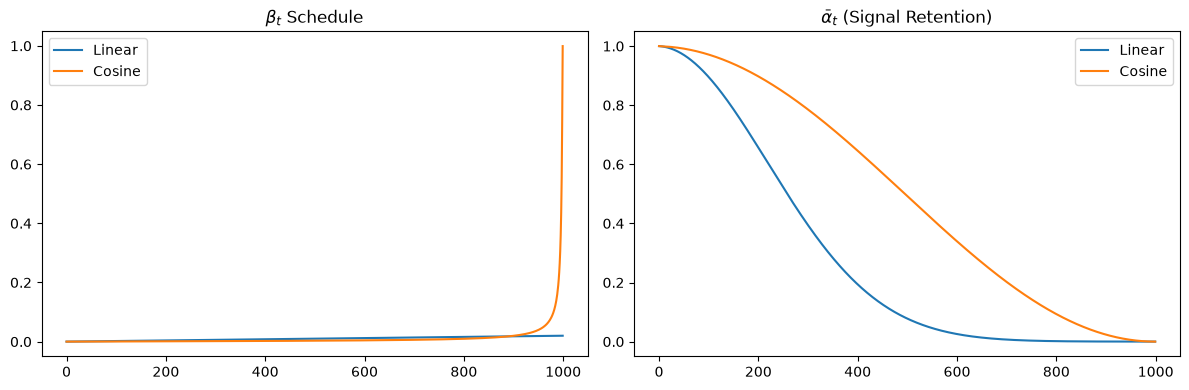

Using 'cosine' beta schedule.


In [58]:
def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    """Original DDPM linear variance schedule."""
    return torch.linspace(beta_start, beta_end, timesteps)

def cosine_beta_schedule(timesteps, s=0.008):
    """Improved cosine schedule (Nichol & Dhariwal, 2021)."""
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 1e-4, 0.999)

def build_diffusion_constants(timesteps=T, schedule=BETA_SCHEDULE):
    """Pre-compute all constants needed for forward/reverse diffusion."""
    betas = cosine_beta_schedule(timesteps) if schedule == 'cosine' \
            else linear_beta_schedule(timesteps)
    alphas              = 1.0 - betas
    alphas_cumprod      = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    posterior_variance  = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    return dict(
        betas                        = betas,
        alphas                       = alphas,
        alphas_cumprod               = alphas_cumprod,
        alphas_cumprod_prev          = alphas_cumprod_prev,
        sqrt_alphas_cumprod          = torch.sqrt(alphas_cumprod),
        sqrt_one_minus_alphas_cumprod= torch.sqrt(1.0 - alphas_cumprod),
        posterior_variance           = posterior_variance,
        posterior_log_var_clipped    = torch.log(posterior_variance.clamp(min=1e-20)),
    )

DIFF     = build_diffusion_constants()
DIFF_GPU = {k: v.to(DEVICE) for k, v in DIFF.items()}

# Visualize schedules
blin = linear_beta_schedule(T); bcos = cosine_beta_schedule(T)
alin = torch.cumprod(1-blin, 0); acos = torch.cumprod(1-bcos, 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(blin.numpy(), label='Linear'); axes[0].plot(bcos.numpy(), label='Cosine')
axes[0].set_title(r'$\beta_t$ Schedule'); axes[0].legend()
axes[1].plot(alin.numpy(), label='Linear'); axes[1].plot(acos.numpy(), label='Cosine')
axes[1].set_title(r'$\bar{\alpha}_t$ (Signal Retention)'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Using {BETA_SCHEDULE!r} beta schedule.')

### 3.2 Helper Functions

In [59]:
def extract(a, t, x_shape):
    """Gather values from tensor `a` at indices `t`, shaped for broadcasting."""
    out = a.gather(-1, t.to(a.device))
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1))).to(t.device)

def q_sample(x_start, t, noise=None):
    """Forward diffusion step:"""
    if noise is None:
        noise = torch.randn_like(x_start)
    s1 = extract(DIFF_GPU['sqrt_alphas_cumprod'],           t, x_start.shape)
    s2 = extract(DIFF_GPU['sqrt_one_minus_alphas_cumprod'], t, x_start.shape)
    return s1 * x_start + s2 * noise

def show_images(images, title='', n=10, save_path=None):
    """Display a row of images (tensor [B,C,H,W] in [-1,1])."""
    n = min(n, images.shape[0])
    fig, axes = plt.subplots(1, n, figsize=(n * 1.6, 1.9))
    fig.suptitle(title, fontsize=11)
    for i, ax in enumerate(axes):
        img = (images[i].clamp(-1, 1) + 1) / 2
        ax.imshow(img.permute(1, 2, 0).cpu().numpy())
        ax.axis('off')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

def plot_training_curve(losses, save_path=None):
    w = max(1, len(losses) // 50)
    sm = np.convolve(losses, np.ones(w)/w, mode='valid')
    plt.figure(figsize=(10, 4))
    plt.plot(losses, alpha=0.25, color='steelblue')
    plt.plot(np.arange(w-1, len(losses)), sm, color='steelblue', label='Smoothed')
    plt.xlabel('Iteration'); plt.ylabel('MSE Loss')
    plt.title('Training Loss'); plt.legend(); plt.grid(alpha=0.3)
    if save_path: plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

class EMA:
    """Exponential Moving Average for stabilised model weights."""
    def __init__(self, model, decay=EMA_DECAY, update_every=5):  # <-- new
        self.decay        = decay
        self.update_every = update_every
        self._step        = 0
        self.shadow = copy.deepcopy(model).eval()
        for p in self.shadow.parameters(): p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        self._step += 1
        if self._step % self.update_every != 0:   # <-- skip most steps
            return
        for s, p in zip(self.shadow.parameters(), model.parameters()):
            s.data.lerp_(p.data, 1 - self.decay)

    def ema_model(self): return self.shadow

print('Utils ready.')

Utils ready.


---
## 4. Data
### 4.1 Load CIFAR-10

In [60]:
CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

_norm = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))   # → [-1, 1]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    _norm
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    _norm
])

def load_cifar10(data_dir: str, train_transform, eval_transform):
    """Download CIFAR-10 with automatic fallback for blocked HTTP sources."""
    import os, tarfile, shutil

    cifar_flag = os.path.join(data_dir, "cifar-10-batches-py", "batches.meta")

    # Already extracted
    if os.path.exists(cifar_flag):
        print("CIFAR-10 already on disk — skipping download.")
        return (
            datasets.CIFAR10(data_dir, train=True,  download=False, transform=train_transform),
            datasets.CIFAR10(data_dir, train=False, download=False, transform=eval_transform)
        )

    # torchvision default download
    try:
        print("CIFAR-10 downloaded via torchvision default URL.")
        return (
            datasets.CIFAR10(data_dir, train=True,  download=True, transform=train_transform),
            datasets.CIFAR10(data_dir, train=False, download=True, transform=eval_transform)
        )
    except Exception as e:
        print(f"torchvision default failed ({e}). Trying mirrors ...")

    # Direct wget from cs.toronto.edu
    tar_path = os.path.join(data_dir, "cifar-10-python.tar.gz")
    os.makedirs(data_dir, exist_ok=True)
    mirrors = [
        "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz",
        "https://storage.googleapis.com/kaggle-data-sets/10400/14988/bundle/archive.tar?GoogleAccessId=databundle-worker-v2@kaggle-161607.iam.gserviceaccount.com",
    ]
    for url in mirrors:
        try:
            print(f"Fetching from {url[:60]} ...")
            import urllib.request
            urllib.request.urlretrieve(url, tar_path)
            with tarfile.open(tar_path) as tf:
                tf.extractall(data_dir)
            os.remove(tar_path)
            print("Mirror download successful.")
            return (
                datasets.CIFAR10(data_dir, train=True,  download=False, transform=train_transform),
                datasets.CIFAR10(data_dir, train=False, download=False, transform=eval_transform)
            )
        except Exception as e:
            print(f"  Mirror failed: {e}")

    raise RuntimeError(
        "All CIFAR-10 download methods failed.\n"
        "Manual fix — run this in a cell:\n"
        "  !wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz -P ./data\n"
        "  !tar -xzf ./data/cifar-10-python.tar.gz -C ./data"
    )

train_dataset, eval_dataset = load_cifar10(DATA_DIR, train_transform, eval_transform)

_loader_kw = dict(pin_memory=True, drop_last=True,
                  persistent_workers=(NUM_WORKERS > 0),
                  prefetch_factor=(4 if NUM_WORKERS > 0 else None))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, **_loader_kw)
eval_loader  = DataLoader(eval_dataset,  batch_size=EVAL_BATCH, shuffle=False,
                          num_workers=min(NUM_WORKERS, 2),
                          pin_memory=True, drop_last=False,
                          persistent_workers=(NUM_WORKERS > 0),
                          prefetch_factor=(4 if NUM_WORKERS > 0 else None))

print(f'Train : {len(train_dataset):,} images  ({len(train_loader):,} batches)')
print(f'Test  : {len(eval_dataset):,} images')
print(f'Shape : {train_dataset[0][0].shape}')

CIFAR-10 already on disk — skipping download.
Train : 50,000 images  (97 batches)
Test  : 10,000 images
Shape : torch.Size([3, 32, 32])


### 4.2 Visualise Real Images & Forward Process

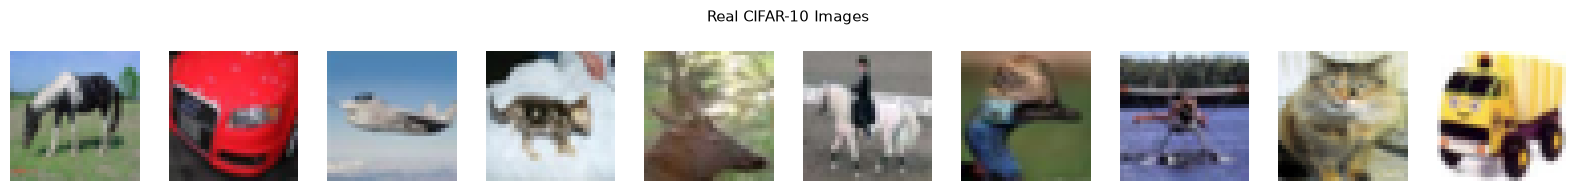

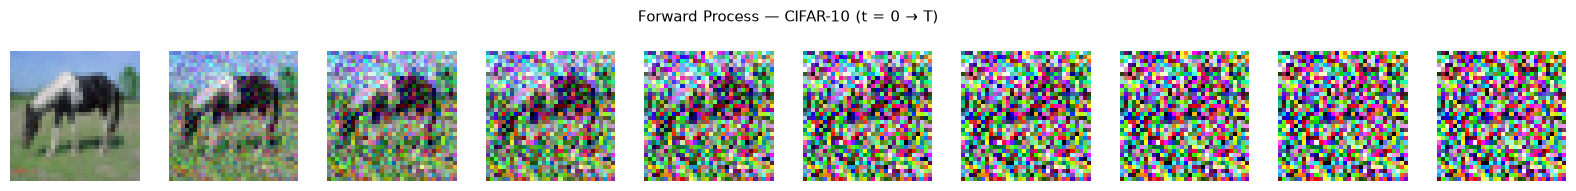

In [61]:
real_batch, _ = next(iter(train_loader))
show_images(real_batch, title='Real CIFAR-10 Images')

# Forward process on a single image
sample_img = real_batch[0:1].to(DEVICE)
fixed_noise = torch.randn_like(sample_img)
timesteps_vis = torch.linspace(0, T-1, 10).long()

noised = []
for t_val in timesteps_vis:
    t_tensor = torch.tensor([t_val], device=DEVICE)
    noised.append(q_sample(sample_img, t_tensor, noise=fixed_noise))
show_images(torch.cat(noised, 0), title='Forward Process — CIFAR-10 (t = 0 → T)')

---
## 5. Network
### 5.1 Building Blocks

In [62]:
class SinusoidalPositionEmbeddings(nn.Module):
    """Sinusoidal timestep embeddings (identical to Transformer PE)."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device, half = time.device, self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=device) * -emb)
        emb = time[:, None].float() * emb[None, :]
        return torch.cat((emb.sin(), emb.cos()), dim=-1)

class ResBlock(nn.Module):
    """Residual block with GroupNorm, SiLU, and AdaGN timestep conditioning."""
    def __init__(self, in_ch, out_ch, time_emb_dim, n_groups=NUM_GROUPS):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_ch * 2))
        self.norm1    = nn.GroupNorm(n_groups, in_ch)
        self.conv1    = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.norm2    = nn.GroupNorm(n_groups, out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.act      = nn.SiLU()
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        scale, shift = self.time_mlp(t_emb).chunk(2, dim=-1)
        scale = scale[:, :, None, None];
        shift = shift[:, :, None, None]
        h = self.conv1(self.act(self.norm1(x)))
        h = h * (1 + scale) + shift
        h = self.conv2(self.act(self.norm2(h)))
        return h + self.res_conv(x)

class SelfAttention(nn.Module):
    """Multi-head self-attention using scaled_dot_product_attention (Flash Attention)."""
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm     = nn.GroupNorm(NUM_GROUPS, channels)
        self.heads    = num_heads
        self.head_dim = channels // num_heads
        self.qkv  = nn.Linear(channels, channels * 3, bias=False)
        self.proj = nn.Linear(channels, channels)

    def forward(self, x):
        B, C, H, W = x.shape
        h       = self.norm(x).view(B, C, H*W).permute(0, 2, 1)          # B, N, C
        qkv     = self.qkv(h).reshape(B, H*W, 3, self.heads, self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)                                      # B, heads, N, head_dim
        # Uses Flash Attention when available (PyTorch 2+), falls back to standard otherwise
        out = torch.nn.functional.scaled_dot_product_attention(q, k, v)
        out = out.permute(0, 2, 1, 3).reshape(B, H*W, C)
        out = self.proj(out).permute(0, 2, 1).view(B, C, H, W)
        return x + out

class Downsample(nn.Module):
    def __init__(self, ch): super().__init__(); self.c = nn.Conv2d(ch, ch, 3, stride=2, padding=1)
    def forward(self, x): return self.c(x)

class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.c = nn.Conv2d(ch, ch, 3, padding=1)   # regular conv, not transpose
    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.c(x)

print('Building blocks defined.')

Building blocks defined.


### 5.2 U-Net

In [63]:
class UNet(nn.Module):
    """Lightweight U-Net for DDPM noise prediction."""
    def __init__(self, in_ch=IN_CHANNELS, dim=MODEL_DIM,
                 dim_mults=DIM_MULTS, t_dim=TIME_EMB_DIM):
        super().__init__()
        dims = [dim * m for m in dim_mults]

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(dim),
            nn.Linear(dim, t_dim), nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )
        self.init_conv = nn.Conv2d(in_ch, dim, 3, padding=1)

        # Encoder
        self.encoder = nn.ModuleList()
        curr = dim
        self.skip_chs = [curr]
        for i, d in enumerate(dims):
            self.encoder.append(nn.ModuleList([
                ResBlock(curr, d, t_dim),
                ResBlock(d,    d, t_dim),
                nn.Identity() if i == len(dims)-1 else Downsample(d),
            ]))
            curr = d; self.skip_chs.append(curr)

        # Bottleneck
        self.mid1  = ResBlock(curr, curr, t_dim)
        self.attn  = SelfAttention(curr)
        self.mid2  = ResBlock(curr, curr, t_dim)

        # Decoder
        self.decoder = nn.ModuleList()
        for i, d in enumerate(reversed(dims)):
            sk = self.skip_chs[-(i+1)]
            self.decoder.append(nn.ModuleList([
                ResBlock(curr + sk, d, t_dim),
                ResBlock(d,         d, t_dim),
                nn.Identity() if i == len(dims)-1 else Upsample(d),
            ]))
            curr = d

        self.final_norm = nn.GroupNorm(NUM_GROUPS, curr)
        self.out_conv   = nn.Conv2d(curr, in_ch, 1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x     = self.init_conv(x)
        skips = [x]
        for r1, r2, down in self.encoder:
            x = r1(x, t_emb); x = r2(x, t_emb)
            skips.append(x); x = down(x)
        x = self.mid1(x, t_emb); x = self.attn(x); x = self.mid2(x, t_emb)
        for r1, r2, up in self.decoder:
            x = torch.cat([x, skips.pop()], dim=1)
            x = r1(x, t_emb); x = r2(x, t_emb); x = up(x)
        return self.out_conv(F.silu(self.final_norm(x)))

model = UNet().to(DEVICE)
if hasattr(torch, "compile") and DEVICE.type == "cuda":
    model = torch.compile(model, mode="reduce-overhead")
    print("Model compiled with torch.compile(mode='reduce-overhead').")

ema   = EMA(model)
n_p   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net parameters : {n_p/1e6:.2f} M')

# Sanity-check forward pass
with torch.no_grad():
    _x = torch.randn(4, IN_CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    _t = torch.randint(0, T, (4,), device=DEVICE).long()
    _o = model(_x, _t)
print(f'Input  : {_x.shape}  ->  Output : {_o.shape}  OK')

U-Net parameters : 3.32 M
Input  : torch.Size([4, 3, 32, 32])  ->  Output : torch.Size([4, 3, 32, 32])  OK


---
## 6. Train
### 6.1 Loss & Optimiser

In [64]:
_noise_buf = torch.randn(NOISE_BUFFER_SIZE, IN_CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
_noise_idx = 0

def p_losses(model, x_0, t):
    global _noise_idx
    # Cycle through pre-generated noise instead of sampling fresh each time
    bs         = x_0.shape[0]
    idx        = torch.arange(_noise_idx, _noise_idx + bs) % NOISE_BUFFER_SIZE
    eps        = _noise_buf[idx]
    _noise_idx = (_noise_idx + bs) % NOISE_BUFFER_SIZE

    x_t = q_sample(x_0, t, noise=eps)
    return F.mse_loss(eps, model(x_t, t))

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4, fused=(DEVICE.type == "cuda"))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = torch.cuda.amp.GradScaler("cuda", enabled=(DEVICE.type == 'cuda'))
print('Optimiser configured.')

Optimiser configured.


### 6.2 Training Loop

Epoch  10/100 | Loss 0.0694 | Best 0.0694 | LR 3.90e-04


Epoch  20/100 | Loss 0.0644 | Best 0.0642 | LR 3.62e-04


Epoch  30/100 | Loss 0.0597 | Best 0.0597 | LR 3.18e-04


Epoch  40/100 | Loss 0.0550 | Best 0.0550 | LR 2.62e-04


Epoch  50/100 | Loss 0.0511 | Best 0.0511 | LR 2.00e-04


Epoch  60/100 | Loss 0.0466 | Best 0.0466 | LR 1.38e-04


Epoch  70/100 | Loss 0.0445 | Best 0.0445 | LR 8.24e-05


Epoch  80/100 | Loss 0.0425 | Best 0.0425 | LR 3.82e-05


Epoch  90/100 | Loss 0.0420 | Best 0.0416 | LR 9.79e-06


Epoch 100/100 | Loss 0.0415 | Best 0.0415 | LR 0.00e+00

Training complete!


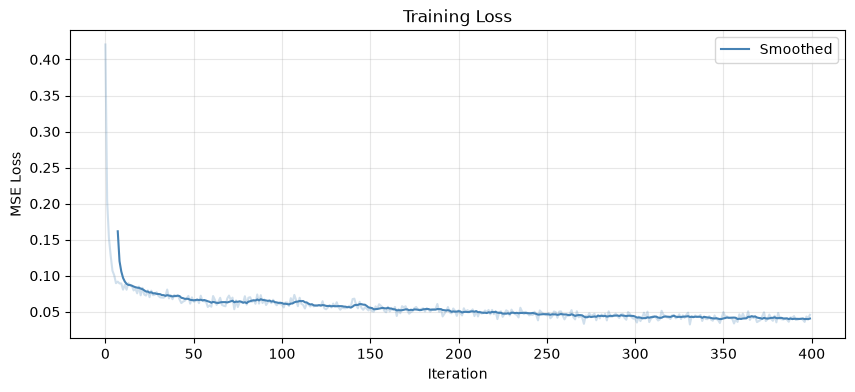

In [65]:
all_losses, epoch_losses, best_loss = [], [], float('inf')

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss_tensor = torch.zeros(1, device=DEVICE)   # stays on GPU
    pbar = tqdm(train_loader, desc=f'Epoch {epoch:3d}/{EPOCHS}', leave=False)
    step = 0  # counts optimizer updates

    optimizer.zero_grad(set_to_none=True)  # reset once before the epoch

    for batch_idx, (images, _) in enumerate(pbar):
        images = images.to(DEVICE, non_blocking=True)
        t      = torch.randint(0, T, (images.shape[0],), device=DEVICE).long()

        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            loss = p_losses(model, images, t)
            loss = loss / ACCUM_STEPS   # scale for accumulation

        scaler.scale(loss).backward()

        if (batch_idx + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            ema.update(model)
            step += 1

        epoch_loss_tensor += loss.detach() * ACCUM_STEPS   # un-scale for logging

        # Low-frequency CPU sync to keep tqdm cheap
        if step % LOG_INTERVAL == 0 and step > 0:
            all_losses.append(loss.item() * ACCUM_STEPS)

    scheduler.step()
    avg = (epoch_loss_tensor / len(train_loader)).item()  # one sync per epoch
    epoch_losses.append(avg)

    if avg < best_loss:
        best_loss = avg
        torch.save({'model': model.state_dict(), 'ema': ema.shadow.state_dict(),
                    'epoch': epoch}, os.path.join(SAVE_DIR, 'best_model.pt'))

    if epoch % 10 == 0 or epoch == EPOCHS:
        print(f'Epoch {epoch:3d}/{EPOCHS} | Loss {avg:.4f} | Best {best_loss:.4f} '
              f'| LR {scheduler.get_last_lr()[0]:.2e}')

print('\nTraining complete!')
plot_training_curve(all_losses, save_path=os.path.join(SAVE_DIR, 'training_curve.png'))

---
## 7. Test
### 7.1 Baseline DDPM Sampler (T=1000 Steps)

DDPM (T=1000) time : 30.7s


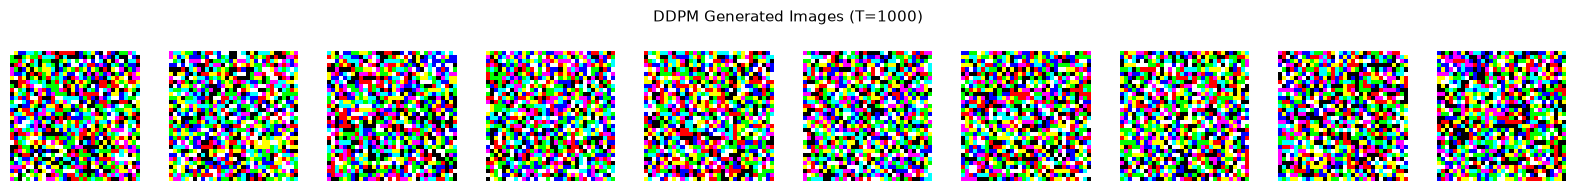

In [66]:
@torch.no_grad()
def ddpm_sample(model, batch_size=16, image_size=IMAGE_SIZE, channels=IN_CHANNELS):
    """Standard DDPM reverse process."""
    model.eval()
    x = torch.randn(batch_size, channels, image_size, image_size, device=DEVICE)
    for i in tqdm(reversed(range(T)), desc='DDPM', total=T, leave=False):
        t_b   = torch.full((batch_size,), i, device=DEVICE, dtype=torch.long)
        pred  = model(x, t_b)
        alpha = DIFF_GPU['alphas'][i]
        abar  = DIFF_GPU['alphas_cumprod'][i]
        beta  = DIFF_GPU['betas'][i]
        mean  = (1/torch.sqrt(alpha)) * (x - (beta/torch.sqrt(1-abar)) * pred)
        if i > 0:
            var = DIFF_GPU['posterior_variance'][i]
            x   = mean + torch.sqrt(var) * torch.randn_like(x)
        else:
            x = mean
    return x.clamp(-1, 1)

eval_model = ema.ema_model()

t0        = time.time()
ddpm_imgs = ddpm_sample(eval_model, batch_size=16)
ddpm_time = time.time() - t0

print(f'DDPM (T=1000) time : {ddpm_time:.1f}s')
show_images(ddpm_imgs, title='DDPM Generated Images (T=1000)',
            save_path=os.path.join(SAVE_DIR, 'ddpm_samples.png'))

### 7.2 DDIM Sampler — Algorithmic Novelty (Accelerated Inference)

DDIM (100 steps) time : 2.8s
Speed-up              : 10.9x


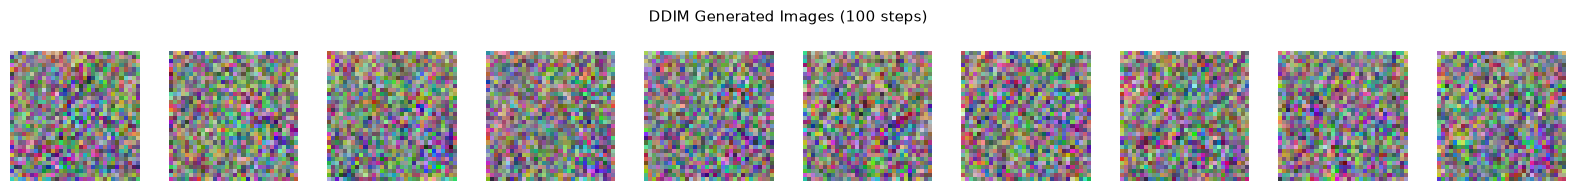

In [67]:
@torch.no_grad()
def ddim_sample(model, steps=100, eta=DDIM_ETA, batch_size=16,
                image_size=IMAGE_SIZE, channels=IN_CHANNELS):
    """DDIM sampling: `steps` NFEs instead of T=1000."""
    model.eval()
    seq      = torch.linspace(0, T-1, steps, dtype=torch.long)
    seq_prev = torch.cat([torch.tensor([-1]), seq[:-1]])
    x        = torch.randn(batch_size, channels, image_size, image_size, device=DEVICE)

    pairs = list(zip(reversed(seq.tolist()), reversed(seq_prev.tolist())))
    for t_cur, t_prev in tqdm(pairs, desc=f'DDIM({steps})', leave=False):
        t_b   = torch.full((batch_size,), t_cur, device=DEVICE, dtype=torch.long)
        abar  = DIFF_GPU['alphas_cumprod'][t_cur]
        ap    = DIFF_GPU['alphas_cumprod'][t_prev] if t_prev >= 0 else torch.tensor(1.0, device=DEVICE)
        pred  = model(x, t_b)
        x0    = ((x - torch.sqrt(1-abar)*pred) / torch.sqrt(abar)).clamp(-1,1)
        sigma = eta * torch.sqrt((1-ap)/(1-abar)) * torch.sqrt(1 - abar/ap)
        dir_  = torch.sqrt(1 - ap - sigma**2) * pred
        noise = torch.randn_like(x) if (eta > 0 and t_prev >= 0) else 0
        x     = torch.sqrt(ap) * x0 + dir_ + sigma * noise
    return x.clamp(-1, 1)

t0           = time.time()
ddim100_imgs = ddim_sample(eval_model, steps=100, batch_size=16)
ddim100_time = time.time() - t0

print(f'DDIM (100 steps) time : {ddim100_time:.1f}s')
print(f'Speed-up              : {ddpm_time/ddim100_time:.1f}x')
show_images(ddim100_imgs, title='DDIM Generated Images (100 steps)',
            save_path=os.path.join(SAVE_DIR, 'ddim100_samples.png'))

### 7.3 FID & Inception Score

In [68]:
def generate_batches(model, sampler_fn, n, **kw):
    """Generate `n` images in mini-batches."""
    out, done = [], 0
    with tqdm(total=n, desc="generating", leave=False) as pbar:
        while done < n:
            bs = min(EVAL_BATCH, n - done)
            out.append(sampler_fn(model, batch_size=bs, **kw).cpu())
            done += bs
            pbar.update(bs)
    return torch.cat(out)[:n]

def compute_metrics(real_loader, gen_images, label=''):
    """FID + IS (with torchmetrics) or proxy metrics (without)."""
    if METRICS_AVAILABLE:
        fid = FrechetInceptionDistance(feature=2048, reset_real_features=True).to(DEVICE)
        isc = InceptionScore(feature='logits_unbiased').to(DEVICE)
        n = 0
        for rb, _ in tqdm(real_loader, desc='FID-real', leave=False):
            u8 = ((rb.clamp(-1,1)+1)/2*255).byte().to(DEVICE)
            fid.update(u8, real=True); n += rb.shape[0]
            if n >= N_EVAL_IMAGES: break
        for i in tqdm(range(0, len(gen_images), EVAL_BATCH), desc='FID-gen', leave=False):
            u8 = ((gen_images[i:i+EVAL_BATCH].clamp(-1,1)+1)/2*255).byte().to(DEVICE)
            fid.update(u8, real=False); isc.update(u8)
        is_m, is_s = isc.compute()
        return {'FID': fid.compute().item(), 'IS_mean': is_m.item(), 'IS_std': is_s.item()}
    else:
        g = gen_images.float()
        return {'proxy_var': g.var().item(), 'proxy_contrast': (g.max()-g.min()).item()}

print(f'Generating {N_EVAL_IMAGES} images for baseline DDPM metrics...')
t0       = time.perf_counter()
ddpm_gen = generate_batches(eval_model, ddpm_sample, N_EVAL_IMAGES)
ddpm_gen_time = time.perf_counter() - t0
ddpm_m   = compute_metrics(eval_loader, ddpm_gen, 'DDPM')
print(f"DDPM generation : {ddpm_gen_time:.1f}s | metrics: {ddpm_m}")

Generating 1000 images for baseline DDPM metrics...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to C:\Users\Yuriy/.cache\torch\hub\checkpoints\weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:09<00:00, 9.78MB/s]


DDPM generation : 1577.1s | metrics: {'FID': 453.8731994628906, 'IS_mean': 1.1680599451065063, 'IS_std': 0.012767020612955093}


### 7.4 Downstream Impact Evaluation — Speed-Up vs. Quality

In [69]:
summary = {}

# Baseline
t0 = time.time()
gen = ddpm_gen  # generate_batches(eval_model, ddpm_sample, N_EVAL_IMAGES)
summary['DDPM (T=1000)'] = {
    'steps':   1000,
    "time":    ddpm_gen_time,
    "metrics": ddpm_m,          # already computed;
}

# DDIM variants
for ns in [100, 10]:
    fn = lambda m, ns=ns, **kw: ddim_sample(m, steps=ns, **kw)
    t0 = time.time()
    gen = generate_batches(eval_model, fn, N_EVAL_IMAGES)
    summary[f'DDIM ({ns} steps)'] = {
        'steps': ns,
        'time': time.time()-t0,
        'metrics': compute_metrics(eval_loader, gen, f'DDIM-{ns}'),
    }

# Print table
base_t = summary['DDPM (T=1000)']['time']
keys   = list(list(summary.values())[0]['metrics'].keys())
hdr    = f'{"Method":<22} {"Steps":>6} {"Time(s)":>8} {"Speed-up":>9}'
for k in keys: hdr += f' {k:>12}'
print('\n' + '='*75)
print(hdr);
print('-'*75)
for name, info in summary.items():
    su  = base_t / info['time']
    row = f'{name:<22} {info["steps"]:>6} {info["time"]:>8.1f} {su:>8.1f}x'
    for k in keys: row += f' {info["metrics"].get(k, float("nan")):>12.4f}'
    print(row)
print('='*75)


Method                  Steps  Time(s)  Speed-up          FID      IS_mean       IS_std
---------------------------------------------------------------------------
DDPM (T=1000)            1000   1577.1      1.0x     453.8732       1.1681       0.0128
DDIM (100 steps)          100    142.8     11.0x     374.3619       1.1861       0.0177
DDIM (10 steps)            10     14.5    109.1x     431.9409       1.2086       0.0201


### 7.5 Fidelity vs. Diversity Study — Ablation on Number of Sampling Steps

We analyse how aggressively reducing sampling steps ($T=1000 \to 100 \to 10$) affects visual quality, comparing the DDPM scheduler against the DDIM acceleration approach.

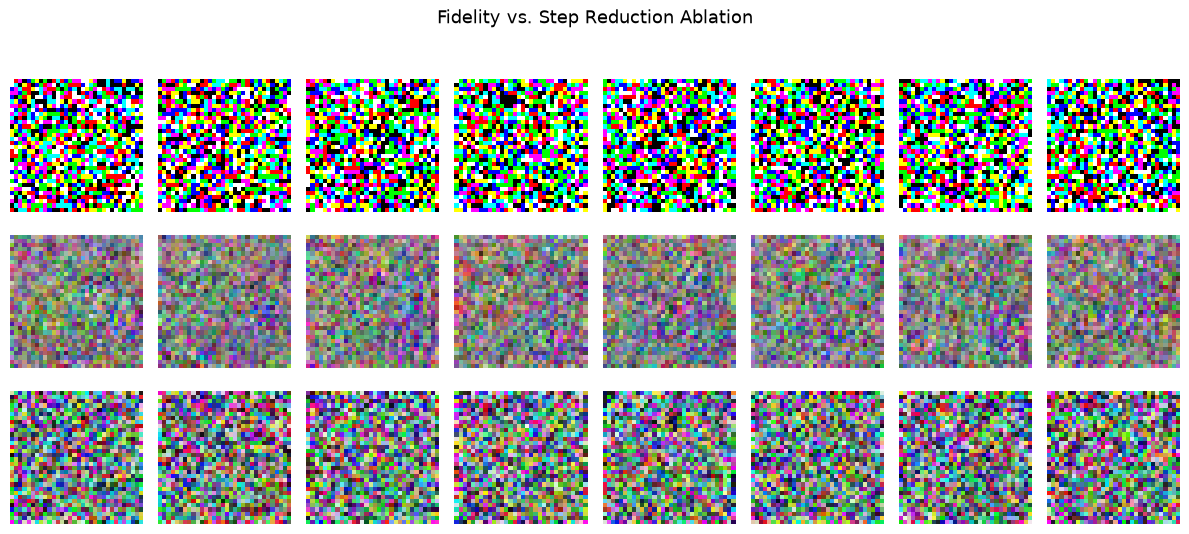

In [70]:
n_show = 8
configs = [
    ('DDPM  T=1000',    lambda m: ddpm_sample(m, batch_size=n_show)),
    ('DDIM  100 steps', lambda m: ddim_sample(m, steps=100, batch_size=n_show)),
    ('DDIM  10 steps',  lambda m: ddim_sample(m, steps=10,  batch_size=n_show)),
]

fig, axes = plt.subplots(len(configs), n_show, figsize=(n_show*1.5, len(configs)*1.8))
fig.suptitle('Fidelity vs. Step Reduction Ablation', fontsize=13, y=1.01)

for r, (lbl, fn) in enumerate(configs):
    imgs = fn(eval_model)
    for c in range(n_show):
        ax  = axes[r][c]
        img = (imgs[c].clamp(-1,1)+1)/2
        ax.imshow(img.permute(1,2,0).cpu().numpy())
        ax.axis('off')
        if c == 0: ax.set_ylabel(lbl, fontsize=9, rotation=90, labelpad=4)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'ablation_steps.png'), dpi=100, bbox_inches='tight')
plt.show()

### 7.6 Summary — Speed-Up vs. Quality Trade-Off

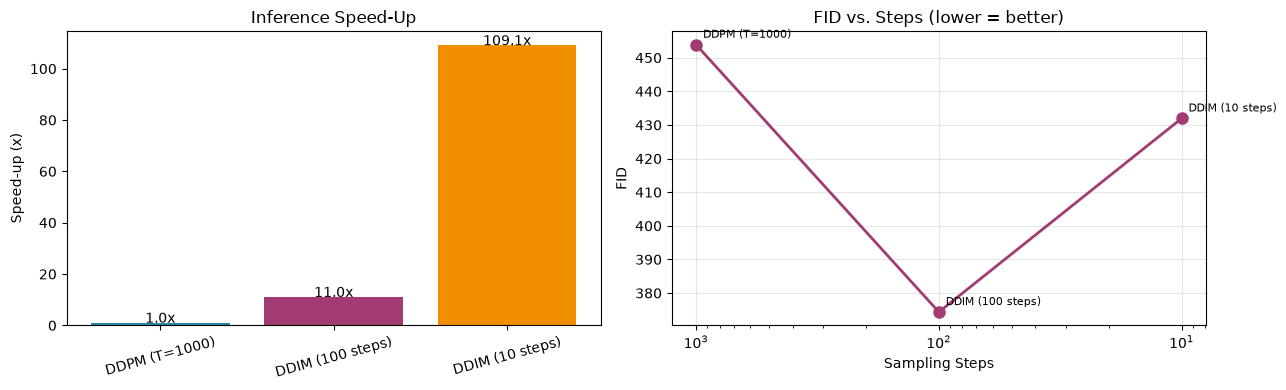

All outputs saved to: ./outputs


In [71]:
mk = list(list(summary.values())[0]['metrics'].keys())
metric_key = 'FID' if 'FID' in mk else mk[0]

names   = list(summary.keys())
speeds  = [base_t / r['time'] for r in summary.values()]
quality = [r['metrics'].get(metric_key, float('nan')) for r in summary.values()]
steps   = [r['steps'] for r in summary.values()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['#2E86AB', '#A23B72', '#F18F01']
axes[0].bar(names, speeds, color=colors)
axes[0].set_ylabel('Speed-up (x)'); axes[0].set_title('Inference Speed-Up')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(speeds):
    axes[0].text(i, v + 0.05, f'{v:.1f}x', ha='center')

axes[1].plot(steps, quality, 'o-', color='#A23B72', lw=2, ms=8)
for s, q, n in zip(steps, quality, names):
    axes[1].annotate(n, (s, q), xytext=(5,5), textcoords='offset points', fontsize=8)
axes[1].set_xlabel('Sampling Steps'); axes[1].set_ylabel(metric_key)
axes[1].set_title(f'{metric_key} vs. Steps (lower = better)')
axes[1].invert_xaxis(); axes[1].set_xscale('log'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'tradeoff.png'), dpi=100, bbox_inches='tight')
plt.show()

print('All outputs saved to:', SAVE_DIR)